## **M&A Arbitrage Strategy** 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### 1. Load & Filter Active Deals
- 使用ListingTrack获得最新 M&A sheet（目前的api平台没有实时更新的mna接口）

In [2]:
DATA_PATH = "../data_preparation/database/mna_listingtrack/ListingTrack | Active Mergers Formatted.csv"
TRADE_DATE = pd.Timestamp("2025-09-05")

raw = pd.read_csv(DATA_PATH)
raw['Est. Closing'] = pd.to_datetime(raw['Est. Closing'], format='%m/%d/%Y', errors='coerce')
raw['Ann. Date'] = pd.to_datetime(raw['Ann. Date'], format='%m/%d/%Y', errors='coerce')
df = raw[raw['Est. Closing'] > TRADE_DATE].copy()
df = df.dropna(subset=['Target Price', 'Cons. Type']) 
print(f"Trade Date: {TRADE_DATE.date()}")
print(f"Total active deals after filtering: {len(df)}")
print(f"Deal types: {df['Cons. Type'].value_counts().to_dict()}")
df[['Symbol', 'Target', 'Acquirer', 'Cons. Type', 'Deal Price', 'Exchange Ratio', 
    'Target Price', 'Trading Spread', 'Est. Closing', 'Progress Tags']].head(15)

Trade Date: 2025-09-05
Total active deals after filtering: 88
Deal types: {'AllCash': 51, 'AllStock': 23, 'CashStock': 14}


,Symbol,Target,Acquirer,Cons. Type,Deal Price,Exchange Ratio,Target Price,Trading Spread,Est. Closing,Progress Tags
14,SOL,Emeren Group Ltd,Shurya Vitra Ltd.,AllCash,2.00,NaN,1.85,0.081081,2025-09-30,DA
15,HLGN,Heliogen Inc.,Zeo Energy,AllStock,NaN,NaN,1.70,NaN,2025-09-30,DA
16,LNSR,"LENSAR, Inc.",Alcon Inc,AllCash,14.00,NaN,11.87,0.179444,2025-09-30,DA
17,BRDG,Bridge Investment Group Holdings Inc.,Apollo Global Management,AllStock,NaN,0.07081,9.60,NaN,2025-09-30,DA
18,IPG,Interpublic Group,Omnicom,AllStock,NaN,0.34400,27.13,NaN,2025-09-30,DA
19,CCRN,Cross Country Healthcare,"Aya Healthcare, Inc.",AllCash,18.61,NaN,12.77,0.457322,2025-09-30,"DA, MergerApproved"
20,SCPH,scPharmaceuticals Inc.,MannKind Corporation,AllCash,5.35,NaN,5.67,-0.056437,2025-10-07,DA
21,VSTA,Vasta Platform Ltd,Cogna Educação S.A.,AllCash,5.00,NaN,4.92,0.016260,2025-10-15,DA
22,ZIMV,ZimVie Inc.,ARCHIMED,AllCash,19.00,NaN,18.99,0.000527,2025-10-20,"DA, MergerApproved"
23,TRML,Tourmaline Bio,Novartis AG,AllCash,48.00,NaN,47.99,0.000208,2025-10-28,DA


### 2. Spread & Annualized Return Calculation

考虑到持有成本：annualized return = spread × (365 / days_to_close)

In [3]:
df['Days_to_Close'] = (df['Est. Closing'] - TRADE_DATE).dt.days

# AllCash deals
cash_mask = df['Cons. Type'] == 'AllCash'
df.loc[cash_mask, 'Gross_Spread'] = df.loc[cash_mask, 'Deal Price'] / df.loc[cash_mask, 'Target Price'] - 1

# AllStock / CashStock
non_cash_mask = df['Cons. Type'].isin(['AllStock', 'CashStock'])
df.loc[non_cash_mask, 'Gross_Spread'] = df.loc[non_cash_mask, 'Trading Spread']
df = df.dropna(subset=['Gross_Spread'])
df['Ann_Return'] = df['Gross_Spread'] * (365 / df['Days_to_Close'])
cols_show = ['Symbol', 'Target', 'Acquirer', 'Cons. Type', 'Deal Price', 'Deal Premium',
             'Target Price', 'Gross_Spread', 'Days_to_Close', 'Ann_Return',
             'Est. Closing', 'Progress Tags', 'Tgt. Sector']
result = df[cols_show].sort_values('Ann_Return', ascending=False).reset_index(drop=True)

print(f"Deals with valid spread: {len(result)}")
result

Deals with valid spread: 50


,Symbol,Target,Acquirer,Cons. Type,Deal Price,Deal Premium,Target Price,Gross_Spread,Days_to_Close,Ann_Return,Est. Closing,Progress Tags,Tgt. Sector
0,CCRN,Cross Country Healthcare,"Aya Healthcare, Inc.",AllCash,18.61,0.67,12.77,0.457322,25,6.676899,2025-09-30,"DA, MergerApproved",Health Care
1,LNSR,"LENSAR, Inc.",Alcon Inc,AllCash,14.00,-0.06,11.87,0.179444,25,2.619882,2025-09-30,DA,Health Care
2,SOL,Emeren Group Ltd,Shurya Vitra Ltd.,AllCash,2.00,0.12,1.85,0.081081,25,1.183784,2025-09-30,DA,Industrials
3,TASK,"TaskUs, Inc.",Blackstone,AllCash,16.50,0.15,14.27,0.156272,117,0.487515,2025-12-31,DA,Industrials
4,TRUE,"TrueCar, Inc.",Fair Holdings (Scott Palmer),AllCash,2.55,0.72,2.34,0.089744,148,0.221327,2026-01-31,DA,Communication Services
5,CTLP,"Cantaloupe, Inc.","365 Retail Markets, LLC",AllCash,11.20,0.18,10.56,0.060606,117,0.189070,2025-12-31,DA,Financials
6,VSTA,Vasta Platform Ltd,Cogna Educação S.A.,AllCash,5.00,0.01,4.92,0.016260,40,0.148374,2025-10-15,DA,Consumer Discretionary
7,TXNM,"TXNM Energy, Inc.",Blackstone,AllCash,61.25,0.16,56.78,0.078725,298,0.096425,2026-06-30,DA,Utilities
8,IMXI,International Money Express Inc,The Western Union Company,AllCash,16.00,0.72,14.86,0.076716,298,0.093964,2026-06-30,DA,Financials
9,RNA,"Avidity Biosciences, Inc.",Novartis AG,AllCash,72.00,0.46,69.92,0.029748,117,0.092804,2025-12-31,DA,Health Care


### 3. Deal Universe Overview

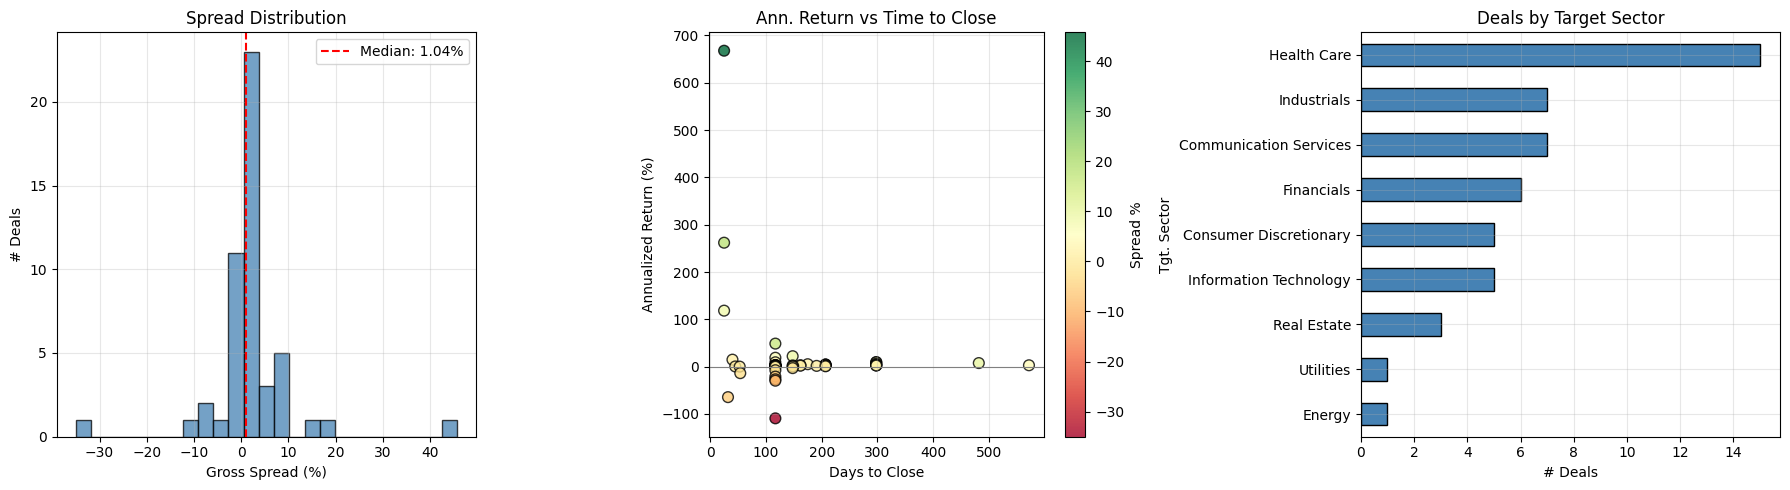

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# spread distribution
axes[0].hist(result['Gross_Spread'] * 100, bins=25, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Gross Spread (%)')
axes[0].set_ylabel('# Deals')
axes[0].set_title('Spread Distribution')
axes[0].axvline(result['Gross_Spread'].median() * 100, color='red', ls='--', label=f"Median: {result['Gross_Spread'].median()*100:.2f}%")
axes[0].legend()

# annualized return vs days to close
scatter = axes[1].scatter(result['Days_to_Close'], result['Ann_Return'] * 100,
                          c=result['Gross_Spread'] * 100, cmap='RdYlGn', 
                          edgecolors='black', s=60, alpha=0.8)
axes[1].set_xlabel('Days to Close')
axes[1].set_ylabel('Annualized Return (%)')
axes[1].set_title('Ann. Return vs Time to Close')
axes[1].axhline(0, color='grey', lw=0.8)
plt.colorbar(scatter, ax=axes[1], label='Spread %')

# deal count by sector
sector_counts = result['Tgt. Sector'].value_counts()
sector_counts.plot.barh(ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_xlabel('# Deals')
axes[2].set_title('Deals by Target Sector')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### 4. Portfolio Construction

筛选逻辑：
1. 只做 positive spread 的 deal（负 spread 说明 target 已经超过 deal price，没有套利空间）
2. 排除 "Blocked" tag 的 deal（监管风险太大）
3. 等权分配资金到每个 deal
4. 假设持有到 Est. Closing 日 deal 成功完成 (现实中此为不合理假设，需要根据历史事件分析confidence score)

In [5]:
CAPITAL = 1_000_000  # 总资金

portfolio = result[(result['Gross_Spread'] > 0) &(~result['Progress Tags'].str.contains('Blocked', na=False))].copy()

n_deals = len(portfolio)
alloc_per_deal = CAPITAL / n_deals

portfolio['Allocation'] = alloc_per_deal
portfolio['Shares'] = (portfolio['Allocation'] / portfolio['Target Price']).astype(int)
portfolio['Actual_Alloc'] = portfolio['Shares'] * portfolio['Target Price']
portfolio['Expected_PnL'] = portfolio['Shares'] * portfolio['Target Price'] * portfolio['Gross_Spread']

total_pnl = portfolio['Expected_PnL'].sum()
total_invested = portfolio['Actual_Alloc'].sum()
weighted_days = (portfolio['Days_to_Close'] * portfolio['Actual_Alloc']).sum() / total_invested
portfolio_return = total_pnl / total_invested
portfolio_ann = portfolio_return * (365 / weighted_days)

print(f"{'='*55}")
print(f"  MNA Arbitrage Portfolio Summary — {TRADE_DATE.date()}")
print(f"{'='*55}")
print(f"  Deals in portfolio:        {n_deals}")
print(f"  Total capital deployed:    ${total_invested:,.0f}")
print(f"  Expected gross P&L:        ${total_pnl:,.0f}")
print(f"  Portfolio gross return:    {portfolio_return*100:.2f}%")
print(f"  Wtd avg days to close:     {weighted_days:.0f}")
print(f"  Annualized gross return:   {portfolio_ann*100:.2f}%")
print(f"{'='*55}")

portfolio[['Symbol', 'Target', 'Cons. Type', 'Target Price', 'Deal Price', 'Gross_Spread', 'Days_to_Close', 'Ann_Return', 'Shares', 'Actual_Alloc', 'Expected_PnL']].head(20)

  MNA Arbitrage Portfolio Summary — 2025-09-05
  Deals in portfolio:        41
  Total capital deployed:    $999,220
  Expected gross P&L:        $43,186
  Portfolio gross return:    4.32%
  Wtd avg days to close:     178
  Annualized gross return:   8.88%


,Symbol,Target,Cons. Type,Target Price,Deal Price,Gross_Spread,Days_to_Close,Ann_Return,Shares,Actual_Alloc,Expected_PnL
0,CCRN,Cross Country Healthcare,AllCash,12.77,18.61,0.457322,25,6.676899,1909,24377.93,11148.56
1,LNSR,"LENSAR, Inc.",AllCash,11.87,14.00,0.179444,25,2.619882,2054,24380.98,4375.02
2,SOL,Emeren Group Ltd,AllCash,1.85,2.00,0.081081,25,1.183784,13183,24388.55,1977.45
3,TASK,"TaskUs, Inc.",AllCash,14.27,16.50,0.156272,117,0.487515,1709,24387.43,3811.07
4,TRUE,"TrueCar, Inc.",AllCash,2.34,2.55,0.089744,148,0.221327,10423,24389.82,2188.83
5,CTLP,"Cantaloupe, Inc.",AllCash,10.56,11.20,0.060606,117,0.189070,2309,24383.04,1477.76
6,VSTA,Vasta Platform Ltd,AllCash,4.92,5.00,0.016260,40,0.148374,4957,24388.44,396.56
7,TXNM,"TXNM Energy, Inc.",AllCash,56.78,61.25,0.078725,298,0.096425,429,24358.62,1917.63
8,IMXI,International Money Express Inc,AllCash,14.86,16.00,0.076716,298,0.093964,1641,24385.26,1870.74
9,RNA,"Avidity Biosciences, Inc.",AllCash,69.92,72.00,0.029748,117,0.092804,348,24332.16,723.84


### 5. Portfolio Visualization

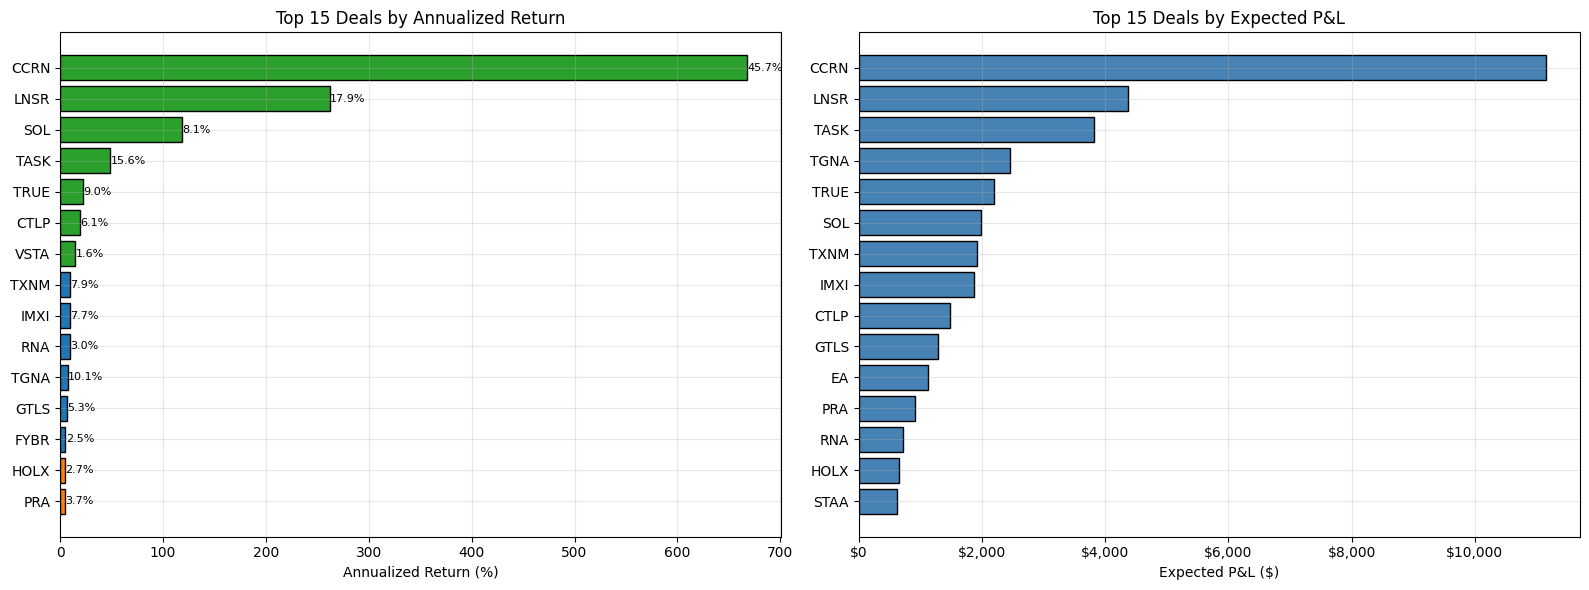

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 deals by annualized return
top15 = portfolio.nlargest(15, 'Ann_Return')
colors = ['#2ca02c' if x > 0.10 else '#1f77b4' if x > 0.05 else '#ff7f0e' for x in top15['Ann_Return']]
bars = axes[0].barh(top15['Symbol'], top15['Ann_Return'] * 100, color=colors, edgecolor='black')
axes[0].set_xlabel('Annualized Return (%)')
axes[0].set_title('Top 15 Deals by Annualized Return')
axes[0].invert_yaxis()
for bar, spread in zip(bars, top15['Gross_Spread']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                 f'{spread*100:.1f}%', va='center', fontsize=8)

# expected P&L by deal
top15_pnl = portfolio.nlargest(15, 'Expected_PnL')
axes[1].barh(top15_pnl['Symbol'], top15_pnl['Expected_PnL'], 
             color='steelblue', edgecolor='black')
axes[1].set_xlabel('Expected P&L ($)')
axes[1].set_title('Top 15 Deals by Expected P&L')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### 6. Timeline — Deal Closing Schedule

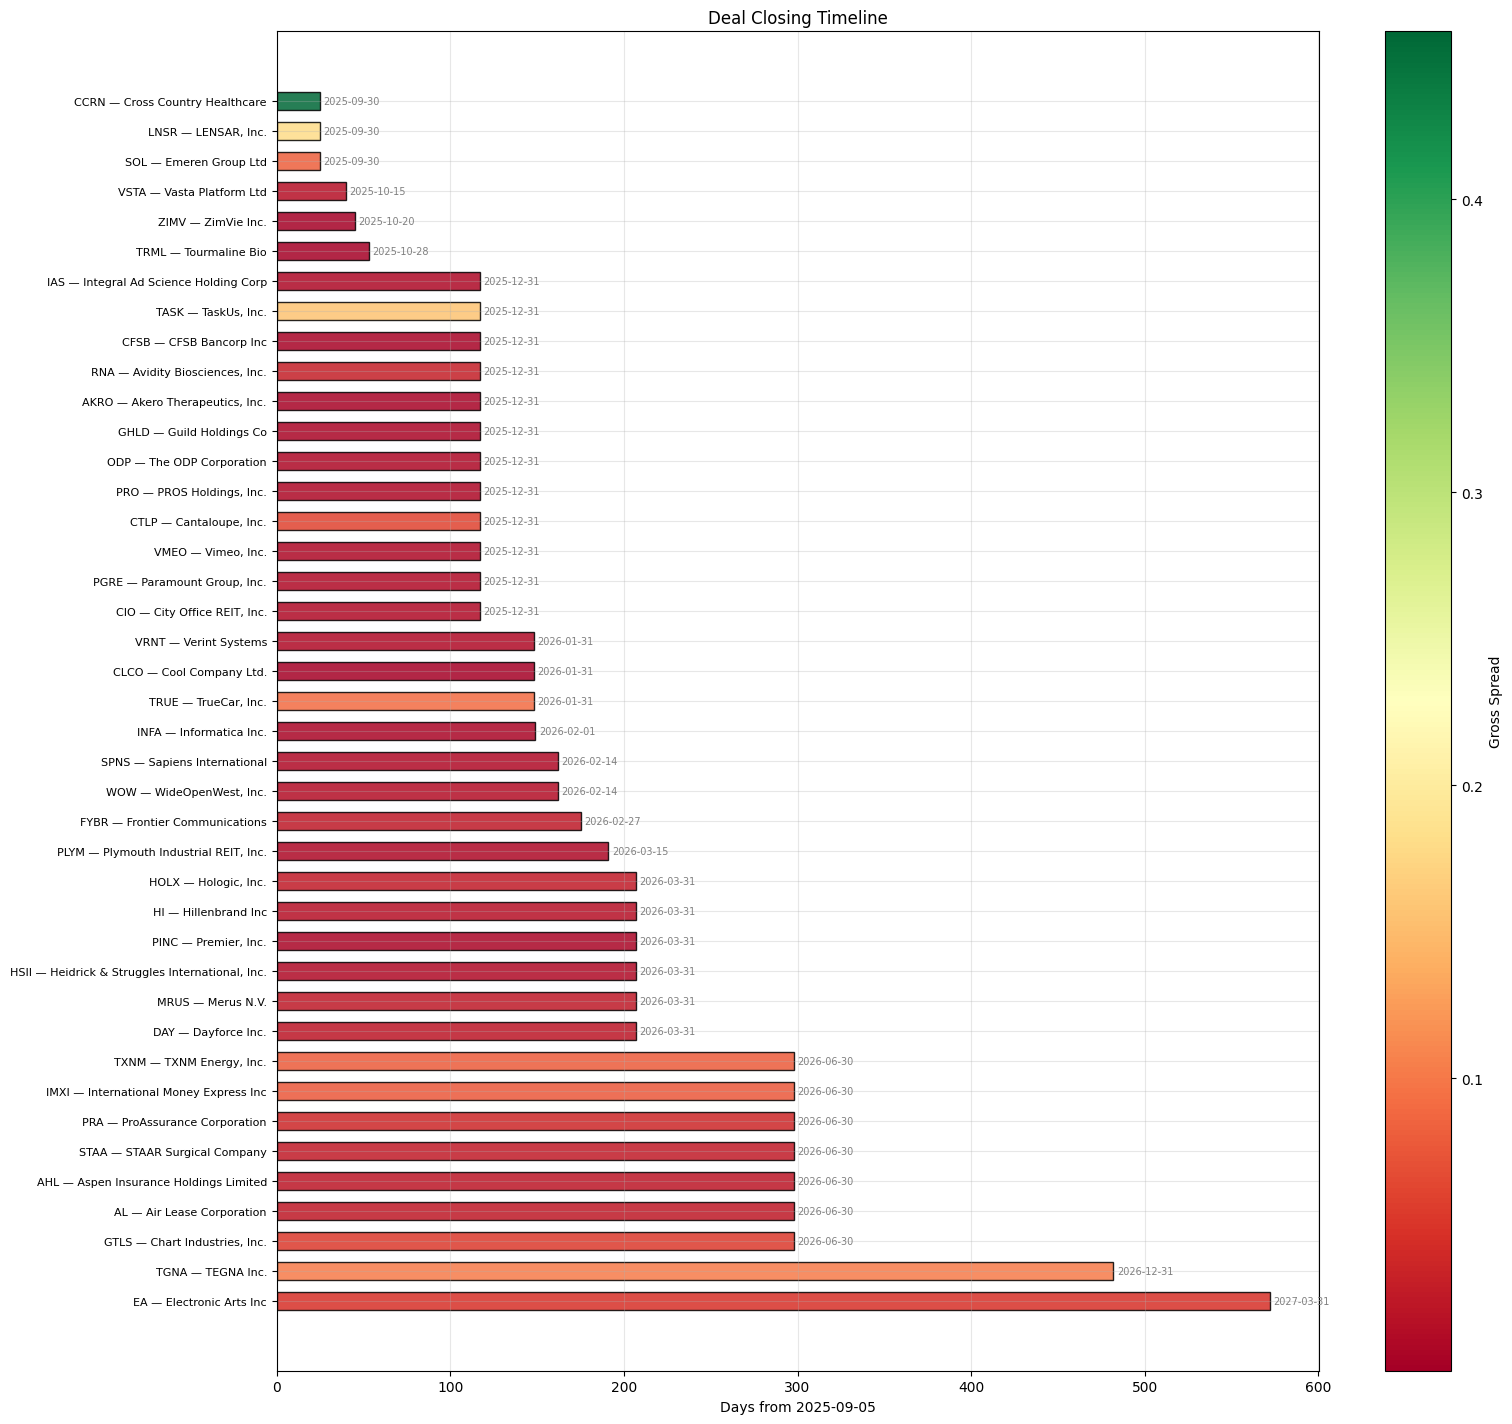

In [7]:
# Gantt-style timeline
fig, ax = plt.subplots(figsize=(16, max(6, len(portfolio) * 0.35)))

sorted_pf = portfolio.sort_values('Est. Closing')
y_pos = range(len(sorted_pf))
bar_starts = [(TRADE_DATE - TRADE_DATE).days] * len(sorted_pf)
bar_lengths = sorted_pf['Days_to_Close'].values
norm = plt.Normalize(sorted_pf['Gross_Spread'].min(), sorted_pf['Gross_Spread'].max())
colors = plt.cm.RdYlGn(norm(sorted_pf['Gross_Spread'].values))
ax.barh(y_pos, bar_lengths, left=bar_starts, height=0.6, color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{s} — {t}" for s, t in zip(sorted_pf['Symbol'], sorted_pf['Target'])], fontsize=8)
ax.set_xlabel(f'Days from {TRADE_DATE.date()}')
ax.set_title('Deal Closing Timeline')
ax.invert_yaxis()

for i, (_, row) in enumerate(sorted_pf.iterrows()):
    ax.text(row['Days_to_Close'] + 2, i, row['Est. Closing'].strftime('%Y-%m-%d'), va='center', fontsize=7, color='grey')

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
plt.colorbar(sm, ax=ax, label='Gross Spread')
plt.tight_layout()
plt.show()

### 7. Risk Analysis — Deal Break Scenario

假设每笔 deal 有一定概率 fail（deal break），target 股价回落到 announcement 前水平。
用 Deal Premium 来估算 downside：如果 deal break，target 大概跌回 Target Price / (1 + Deal Premium)。

In [8]:
DEAL_BREAK_PROB = 0.05  # 假设 5% 概率 deal 失败

risk = portfolio.copy()
risk['Deal Premium'] = risk['Deal Premium'].fillna(risk['Gross_Spread'])  # fallback
risk['Pre_Deal_Price'] = risk['Target Price'] / (1 + risk['Deal Premium'].clip(lower=0.01))
risk['Downside_if_Break'] = (risk['Pre_Deal_Price'] - risk['Target Price']) / risk['Target Price']
risk['Upside_if_Close'] = risk['Gross_Spread']

# Expected return = P(close) * upside + P(break) * downside
risk['E_Return'] = (1 - DEAL_BREAK_PROB) * risk['Upside_if_Close'] + DEAL_BREAK_PROB * risk['Downside_if_Break']
risk['Risk_Reward'] = risk['Upside_if_Close'].abs() / risk['Downside_if_Break'].abs()

print(f"Deal break probability assumed: {DEAL_BREAK_PROB*100:.0f}%\n")
risk_out = risk[['Symbol', 'Target', 'Upside_if_Close', 'Downside_if_Break', 
                  'E_Return', 'Risk_Reward', 'Days_to_Close']].sort_values('E_Return', ascending=False)
risk_out.style.format({
    'Upside_if_Close': '{:.2%}', 'Downside_if_Break': '{:.2%}',
    'E_Return': '{:.2%}', 'Risk_Reward': '{:.2f}x'
})

Deal break probability assumed: 5%



,Symbol,Target,Upside_if_Close,Downside_if_Break,E_Return,Risk_Reward,Days_to_Close
0,CCRN,Cross Country Healthcare,45.73%,-40.12%,41.44%,1.14x,25
1,LNSR,"LENSAR, Inc.",17.94%,-0.99%,17.00%,18.12x,25
3,TASK,"TaskUs, Inc.",15.63%,-13.04%,14.19%,1.20x,117
10,TGNA,TEGNA Inc.,10.06%,-8.26%,9.14%,1.22x,482
2,SOL,Emeren Group Ltd,8.11%,-10.71%,7.17%,0.76x,25
7,TXNM,"TXNM Energy, Inc.",7.87%,-13.79%,6.79%,0.57x,298
4,TRUE,"TrueCar, Inc.",8.97%,-41.86%,6.43%,0.21x,148
8,IMXI,International Money Express Inc,7.67%,-41.86%,5.19%,0.18x,298
5,CTLP,"Cantaloupe, Inc.",6.06%,-15.25%,4.99%,0.40x,117
11,GTLS,"Chart Industries, Inc.",5.28%,-5.01%,4.76%,1.05x,298


### 8. Simulated P&L Curve

假设 deal 按 Est. Closing 顺序逐个 close，资金释放后重新平均分配到剩余 deal。
模拟整个组合在持有期内的累计收益曲线。

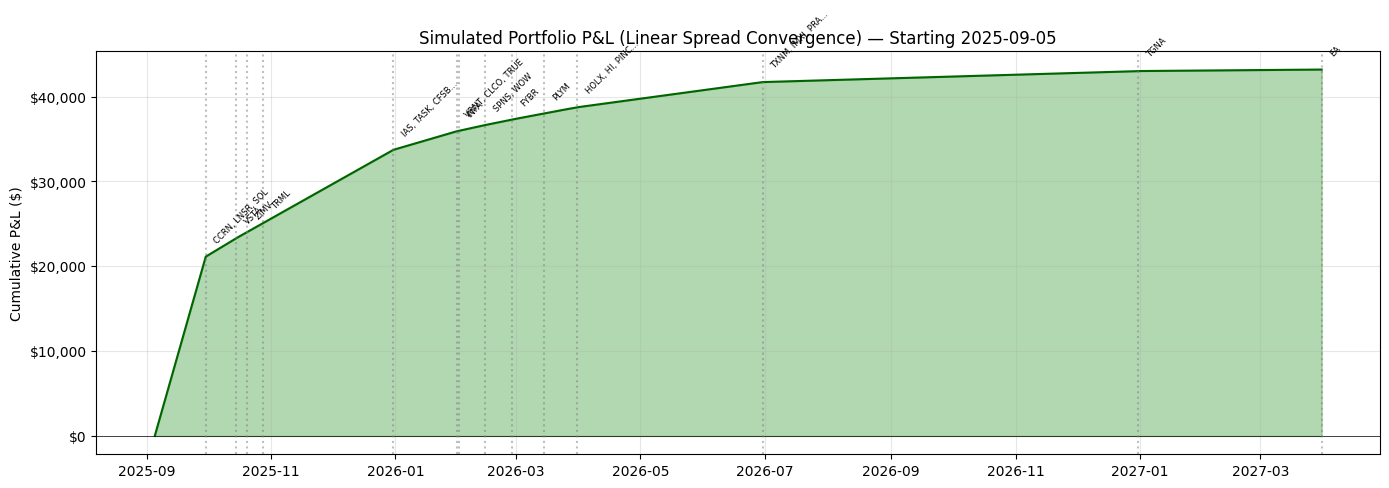


Total simulated P&L: $43,186
Total return on $1,000,000: 4.32%


In [9]:
# Simulation：假设 spread 线性收敛到 0（deal 成功）
sim = portfolio[['Symbol', 'Target', 'Gross_Spread', 'Days_to_Close', 
                  'Est. Closing', 'Actual_Alloc']].copy()
sim = sim.sort_values('Est. Closing')

max_days = int(sim['Days_to_Close'].max())
dates = pd.date_range(TRADE_DATE, periods=max_days + 1, freq='D')
daily_pnl = pd.Series(0.0, index=dates)

for _, deal in sim.iterrows():
    days = int(deal['Days_to_Close'])
    daily_spread_capture = deal['Gross_Spread'] * deal['Actual_Alloc'] / days
    for d in range(1, days + 1):
        dt = TRADE_DATE + pd.Timedelta(days=d)
        if dt in daily_pnl.index:
            daily_pnl[dt] += daily_spread_capture

cum_pnl = daily_pnl.cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(cum_pnl.index, 0, cum_pnl.values, alpha=0.3, color='green')
ax.plot(cum_pnl.index, cum_pnl.values, color='darkgreen', lw=1.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title(f'Simulated Portfolio P&L (Linear Spread Convergence) — Starting {TRADE_DATE.date()}')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axhline(0, color='black', lw=0.5)
closing_dates = sim.groupby('Est. Closing')['Symbol'].apply(list)
for dt, syms in closing_dates.items():
    if dt in cum_pnl.index:
        ax.axvline(dt, color='grey', ls=':', alpha=0.5)
        ax.annotate(', '.join(syms[:3]) + ('...' if len(syms) > 3 else ''),
                    xy=(dt, cum_pnl[dt]), fontsize=6, rotation=45,
                    xytext=(5, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f"\nTotal simulated P&L: ${cum_pnl.iloc[-1]:,.0f}")
print(f"Total return on ${CAPITAL:,.0f}: {cum_pnl.iloc[-1]/CAPITAL*100:.2f}%")

### 9. Trade Sheet

In [10]:
output = portfolio[['Symbol', 'Target', 'Acquirer', 'Cons. Type', 'Deal Price', 'Target Price', 'Gross_Spread', 'Ann_Return', 'Days_to_Close', 'Est. Closing', 'Shares', 'Actual_Alloc', 'Expected_PnL', 'Progress Tags', 'Tgt. Sector']].copy()

output.columns = [
    'Ticker', 'Target', 'Acquirer', 'Type', 'Deal Px', 'Tgt Px',
    'Spread', 'Ann Ret', 'Days', 'Est Close',
    'Shares', 'Notional', 'Exp PnL', 'Status', 'Sector'
]

# formatting
styled = output.style.format({'Deal Px': '${:.2f}', 'Tgt Px': '${:.2f}', 'Spread': '{:.2%}', 'Ann Ret': '{:.2%}', 'Notional': '${:,.0f}', 'Exp PnL': '${:,.0f}', 'Shares': '{:,.0f}'}).background_gradient(subset=['Spread'], cmap='Greens').background_gradient(subset=['Ann Ret'], cmap='RdYlGn')
styled

,Ticker,Target,Acquirer,Type,Deal Px,Tgt Px,Spread,Ann Ret,Days,Est Close,Shares,Notional,Exp PnL,Status,Sector
0,CCRN,Cross Country Healthcare,"Aya Healthcare, Inc.",AllCash,$18.61,$12.77,45.73%,667.69%,25,2025-09-30 00:00:00,"1,909","$24,378","$11,149","DA, MergerApproved",Health Care
1,LNSR,"LENSAR, Inc.",Alcon Inc,AllCash,$14.00,$11.87,17.94%,261.99%,25,2025-09-30 00:00:00,"2,054","$24,381","$4,375",DA,Health Care
2,SOL,Emeren Group Ltd,Shurya Vitra Ltd.,AllCash,$2.00,$1.85,8.11%,118.38%,25,2025-09-30 00:00:00,"13,183","$24,389","$1,977",DA,Industrials
3,TASK,"TaskUs, Inc.",Blackstone,AllCash,$16.50,$14.27,15.63%,48.75%,117,2025-12-31 00:00:00,"1,709","$24,387","$3,811",DA,Industrials
4,TRUE,"TrueCar, Inc.",Fair Holdings (Scott Palmer),AllCash,$2.55,$2.34,8.97%,22.13%,148,2026-01-31 00:00:00,"10,423","$24,390","$2,189",DA,Communication Services
5,CTLP,"Cantaloupe, Inc.","365 Retail Markets, LLC",AllCash,$11.20,$10.56,6.06%,18.91%,117,2025-12-31 00:00:00,"2,309","$24,383","$1,478",DA,Financials
6,VSTA,Vasta Platform Ltd,Cogna Educação S.A.,AllCash,$5.00,$4.92,1.63%,14.84%,40,2025-10-15 00:00:00,"4,957","$24,388",$397,DA,Consumer Discretionary
7,TXNM,"TXNM Energy, Inc.",Blackstone,AllCash,$61.25,$56.78,7.87%,9.64%,298,2026-06-30 00:00:00,429,"$24,359","$1,918",DA,Utilities
8,IMXI,International Money Express Inc,The Western Union Company,AllCash,$16.00,$14.86,7.67%,9.40%,298,2026-06-30 00:00:00,"1,641","$24,385","$1,871",DA,Financials
9,RNA,"Avidity Biosciences, Inc.",Novartis AG,AllCash,$72.00,$69.92,2.97%,9.28%,117,2025-12-31 00:00:00,348,"$24,332",$724,DA,Health Care


### Position Export

In [ ]:
import os, yaml, requests as _req
from pathlib import Path
from datetime import datetime as _dt

with open(Path("../data_preparation/data_apiKey/config.yaml")) as f:
    _fmp_key = yaml.safe_load(f)["keys"]["fmp_api_key"]

def _fmp_ids(tickers, api_key):
    out = {}
    for t in tickers:
        try:
            r = _req.get(f"https://financialmodelingprep.com/stable/profile?symbol={t}&apikey={api_key}", timeout=10)
            d = r.json()
            out[t] = (d[0].get("cusip","") if d else "", d[0].get("isin","") if d else "")
        except Exception:
            out[t] = ("", "")
    return out

day = _dt.now().strftime("%Y%m%d")
tks = output["Ticker"].tolist()
notional = output["Notional"].values.astype(float)
wts = notional / notional.sum()
ids = _fmp_ids(tks, _fmp_key)

df_pos = pd.DataFrame({
    "ticker": tks,
    "cusip": [ids[t][0] for t in tks],
    "isin": [ids[t][1] for t in tks],
    "weight": wts,
    "order_time": "MOC",
    "order_type": "default"
})

out_dir = f"../execution_main/trading_log/{day}"
os.makedirs(out_dir, exist_ok=True)
df_pos.to_csv(f"{out_dir}/strategy_mnaArbitrage_weight.csv", index=False)
print(f"→ {out_dir}/strategy_mnaArbitrage_weight.csv  ({len(df_pos)} rows)")
df_pos